# 篩選出可能對分類模型有用的特徵
所用資料檔：..\data\interim\04_train_feature_selection.csv

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

data_path = Path('..') / 'data' / 'interim' / '04_train_feature_selection.csv'
df = pd.read_csv(data_path)
df.head()


,age,employment_type,monthly_income,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,app_usage_frequency,location,debt_to_income_ratio,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_is_weekend,default_flag
0,46,Student,30440.30,5000.00,Fashion,3,14,1,3.86,Germany,0.164256,2023,3,11,5,1,0
1,46,Unemployed,5412.97,1393.69,Fashion,12,10,1,9.93,Germany,0.257472,2023,2,13,0,0,1
2,24,Student,10466.07,3041.61,Electronics,3,0,0,5.95,Canada,0.290616,2024,7,28,6,1,0
3,19,Unemployed,6335.87,2952.49,Sports,3,13,2,9.69,Germany,0.465996,2023,6,19,0,0,1
4,50,Unemployed,11575.40,3908.83,Beauty,9,8,1,6.20,India,0.337684,2023,6,6,1,0,1


## Nominal 類別
對於以下 Nominal 類別，作卡方檢定看其是否與 `default_flag` 是否有關連。
變數：`employment_type`, `product_category`, `location`, `transaction_is_weekend`

### 1：計算卡方檢定 (Chi-Square Test)

作法： 將每一個類別/序數變數與目標變數 default_flag 建立交叉表（Crosstab），然後計算 p-value。

操作： 將門檻放寬至 p-value < 0.1。只要 p-value 小於 0.1，就代表這個特徵在統計上「稍微」能區分違約狀態，我們先把它留在名單中。

In [2]:
nominal_vars = ['employment_type', 'product_category', 'location', 'transaction_is_weekend']
target_col = 'default_flag'

chi2_rows = []
for col in nominal_vars:
    ctab = pd.crosstab(df[col], df[target_col])
    if ctab.shape[1] < 2:
        print(f'Warning: {col} has only one target class; chi-square skipped.')
        chi2_rows.append({'feature': col, 'chi2': np.nan, 'p_value': np.nan, 'dof': np.nan})
        continue
    chi2, p_value, dof, _ = stats.chi2_contingency(ctab)
    chi2_rows.append({'feature': col, 'chi2': chi2, 'p_value': p_value, 'dof': dof})

chi2_results = pd.DataFrame(chi2_rows).sort_values('p_value')
chi2_results


,feature,chi2,p_value,dof
0,employment_type,346.813165,7.306559e-75,3
1,product_category,10.029645,3.993126e-02,4
3,transaction_is_weekend,0.614742,4.330081e-01,1
2,location,2.944878,7.084839e-01,5


### 步驟 2：計算證據權重 (WoE) 與資訊價值 (IV)

作法： 1. 計算每個類別（例如 location 中的北、中、南）的「違約比例」與「未違約比例」。
2. 透過這兩個比例的對數差算出 WoE (Weight of Evidence)。
3. 將該特徵所有類別的 WoE 加總，即可得到 IV 值。（在 Python 中，建議直接使用 scorecardpy 或 optbinning 套件，可以一鍵算出所有特徵的 IV 值）。

操作：  IV > 0.01 即可保留。

In [3]:
def woe_iv_for_feature(data, feature, target):
    tab = pd.crosstab(data[feature], data[target])
    if 0 not in tab.columns or 1 not in tab.columns:
        print(f'Warning: {feature} has only one target class; IV set to NaN.')
        return np.nan
    tab = tab.reindex(columns=[0, 1], fill_value=0)
    good = tab[0].sum()
    bad = tab[1].sum()
    if good == 0 or bad == 0:
        print(f'Warning: {feature} has zero count in a target class; IV set to NaN.')
        return np.nan
    dist_good = tab[0] / good
    dist_bad = tab[1] / bad
    eps = 1e-9
    woe = np.log((dist_good + eps) / (dist_bad + eps))
    iv = ((dist_good - dist_bad) * woe).sum()
    return iv

iv_rows = []
for col in nominal_vars:
    iv = woe_iv_for_feature(df, col, target_col)
    iv_rows.append({'feature': col, 'iv': iv})

iv_results = pd.DataFrame(iv_rows).sort_values('iv', ascending=False)
iv_results


,feature,iv
0,employment_type,0.181375
1,product_category,0.005079
2,location,0.001494
3,transaction_is_weekend,0.000333


### 步驟 3：綜合篩選準則 (Decision Rule)

針對所有類別與序數特徵，執行以下過濾邏輯：

IV > 0.01 或是 卡方檢定的 p-value < 0.1，就列出。

In [4]:
decision_summary = chi2_results.merge(iv_results, on='feature', how='left')
decision_summary['keep'] = (decision_summary['iv'] > 0.01) | (decision_summary['p_value'] < 0.1)
decision_summary.sort_values(['keep', 'p_value'], ascending=[False, True])


,feature,chi2,p_value,dof,iv,keep
0,employment_type,346.813165,7.306559e-75,3,0.181375,True
1,product_category,10.029645,3.993126e-02,4,0.005079,True
2,transaction_is_weekend,0.614742,4.330081e-01,1,0.000333,False
3,location,2.944878,7.084839e-01,5,0.001494,False


### 結論
`employment_type`, `product_category` 符合條件，假定其與 `default_flag` 有關

## Ordinal, Interval, Ratio 類別

連續與等比型變數 (Ratio/Interval)： 由於金融特徵（如 monthly_income, debt_to_income_ratio）多具備嚴重偏態，採 Mann-Whitney U 檢定 (Wilcoxon Rank-Sum Test)，測試在 `default_flag` = 1 與 0 情況下，ordinal, interval, ratio 分布是否有所不同。(篩出 p-value < 0.1 的項目)

| Type | Variables |
| :--- | :--- |
| ordinal | `bnpl_installments`,  `missed_payments`|
| interval | `transaction_year`, `transaction_month`,`transaction_day`, `transaction_dayofweek`  |
| ratio | `age`, `monthly_income`, `purchase_amount`, `repayment_delay_days`, `app_usage_frequency`, `debt_to_income_ratio` |

先劃出這些變數的 histogram 疊圖，再顯示其檢定結果

In [5]:
ordinal_vars = ['bnpl_installments', 'missed_payments']
interval_vars = ['transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek']
ratio_vars = ['age', 'monthly_income', 'purchase_amount', 'repayment_delay_days', 'app_usage_frequency', 'debt_to_income_ratio']

def plot_hist_by_target(data, feature, target='default_flag', bins=30):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(data[data[target] == 0][feature].dropna(), bins=bins, alpha=0.6, label='default=0')
    ax.hist(data[data[target] == 1][feature].dropna(), bins=bins, alpha=0.6, label='default=1')
    ax.set_title(f'{feature} distribution by {target}')
    ax.set_xlabel(feature)
    ax.set_ylabel('count')
    ax.legend()
    plt.show()

def mannwhitney_pvalue(series, target_series):
    group0 = series[target_series == 0].dropna()
    group1 = series[target_series == 1].dropna()
    if len(group0) == 0 or len(group1) == 0:
        print('Warning: one of the groups is empty; p-value set to NaN.')
        return np.nan
    return stats.mannwhitneyu(group0, group1, alternative='two-sided').pvalue


### Ordinal
僅 `missed_payments` 統計顯著，假定只有 `missed_payments` 可能對 `default_flag` 有影響

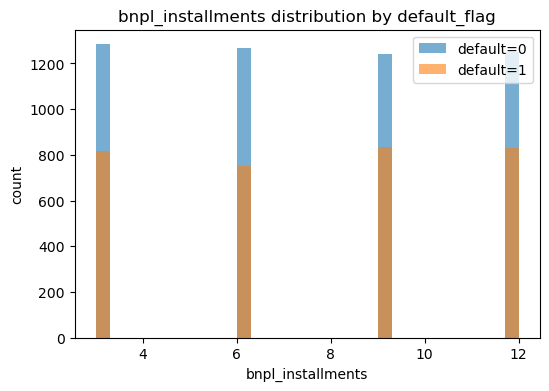

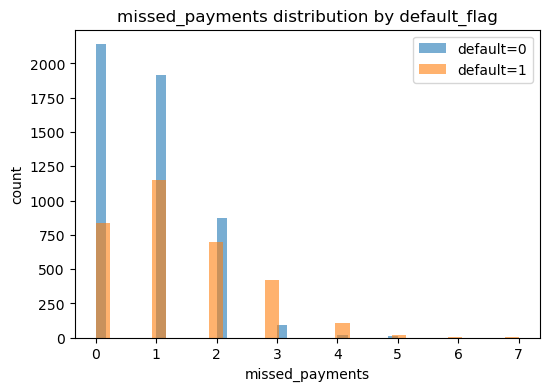

,feature,p_value,keep
0,bnpl_installments,1.832147e-01,False
1,missed_payments,3.489644e-104,True


In [9]:
ordinal_rows = []
for col in ordinal_vars:
    plot_hist_by_target(df, col, target_col)
    p_value = mannwhitney_pvalue(df[col], df[target_col])
    ordinal_rows.append({'feature': col, 'p_value': p_value})

ordinal_results = pd.DataFrame(ordinal_rows)
ordinal_results['keep'] = ordinal_results['p_value'] < 0.1
ordinal_results


### Interval
僅 `transaction_dayofweek` 統計顯著，假定只有 `transaction_dayofweek` 可能對 `default_flag` 有影響

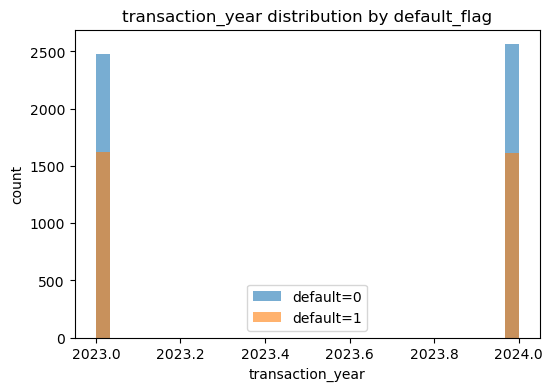

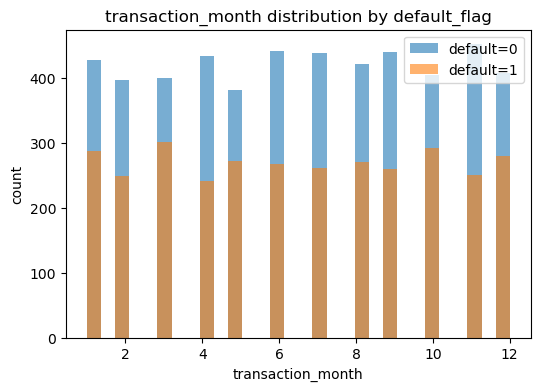

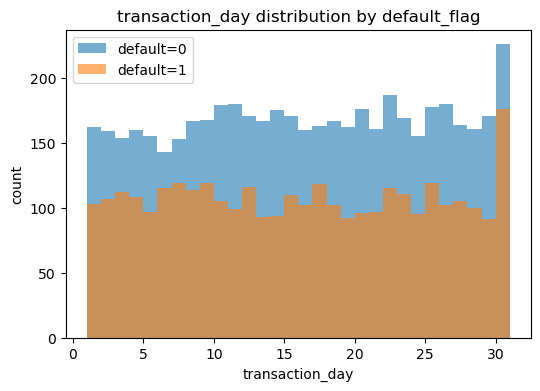

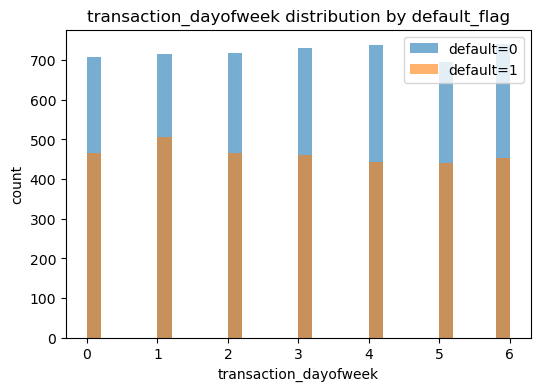

,feature,p_value,keep
0,transaction_year,0.421455,False
1,transaction_month,0.502206,False
2,transaction_day,0.244397,False
3,transaction_dayofweek,0.096541,True


In [10]:
interval_rows = []
for col in interval_vars:
    plot_hist_by_target(df, col, target_col)
    p_value = mannwhitney_pvalue(df[col], df[target_col])
    interval_rows.append({'feature': col, 'p_value': p_value})

interval_results = pd.DataFrame(interval_rows)
interval_results['keep'] = interval_results['p_value'] < 0.1
interval_results


### ratio

`age`, `monthly_income`, `purchase_amount`, `repayment_delay_days`, `debt_to_income_ratio` 統計顯著，假定只有 `age`, `monthly_income`, `purchase_amount`, `repayment_delay_days`, `debt_to_income_ratio` 可能對 `default_flag` 有影響

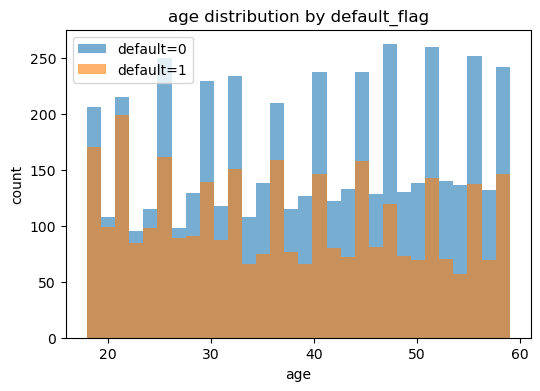

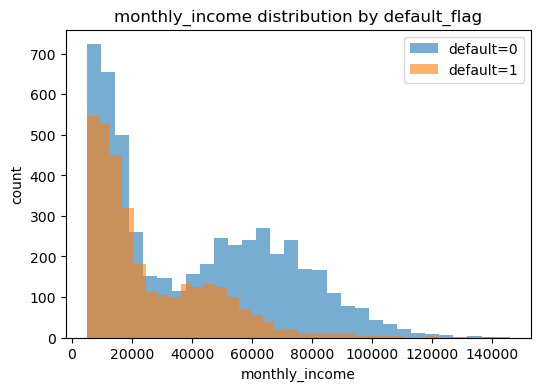

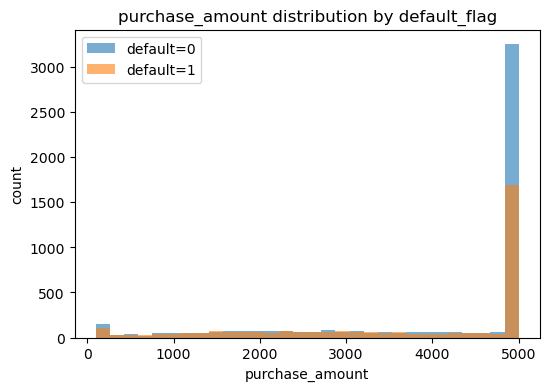

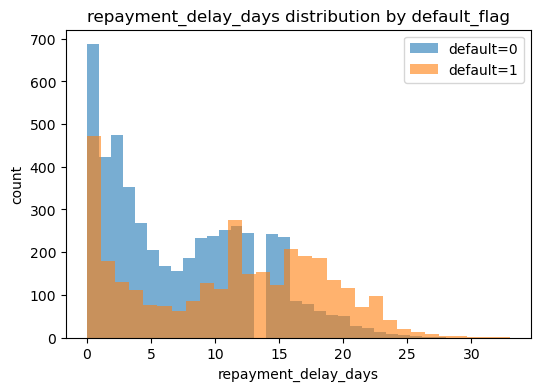

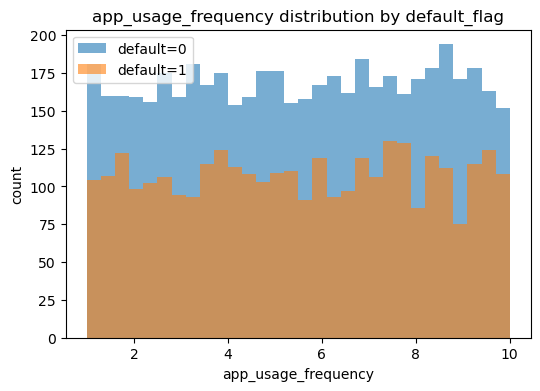

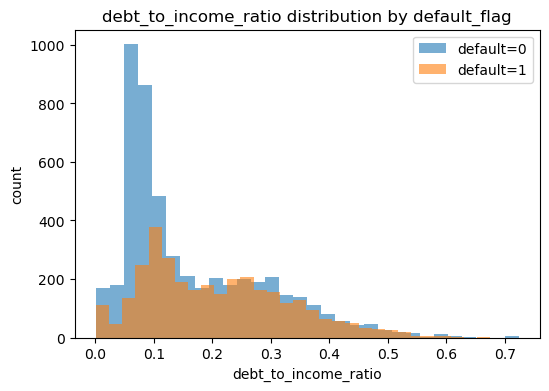

,feature,p_value,keep
0,age,1.303283e-12,True
1,monthly_income,1.001820e-107,True
2,purchase_amount,2.425125e-27,True
3,repayment_delay_days,4.317786e-122,True
4,app_usage_frequency,9.420043e-01,False
5,debt_to_income_ratio,4.009355e-85,True


In [12]:
ratio_rows = []
for col in ratio_vars:
    plot_hist_by_target(df, col, target_col)
    p_value = mannwhitney_pvalue(df[col], df[target_col])
    ratio_rows.append({'feature': col, 'p_value': p_value})

ratio_results = pd.DataFrame(ratio_rows)
ratio_results['keep'] = ratio_results['p_value'] < 0.1
ratio_results


## Spearman 檢查

### 1.計算相關係數矩陣
將篩出來的的連續型（Ratio/Interval）與序數型（Ordinal）變數丟入，畫出 Spearman 相關係數矩陣。

| Type | Variables |
| :--- | :--- |
| ordinal | `missed_payments` |
| interval |  `transaction_dayofweek` |
| ratio | `age`, `monthly_income`, `purchase_amount`, `repayment_delay_days`,  `debt_to_income_ratio` |

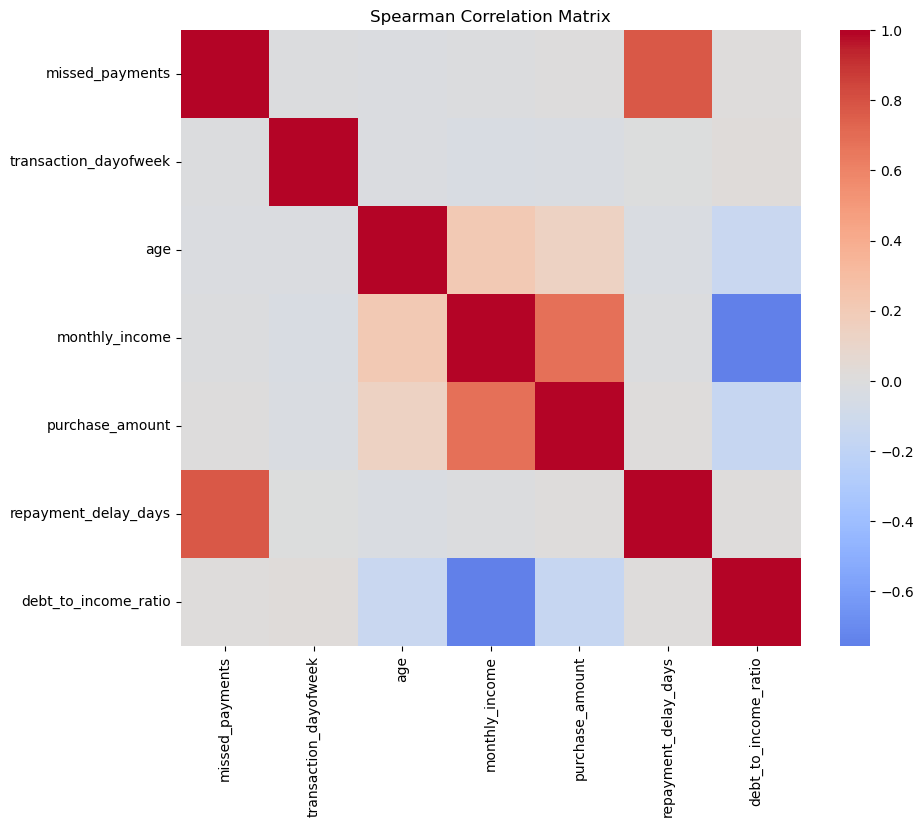

In [13]:
spearman_vars = ['missed_payments', 'transaction_dayofweek', 'age', 'monthly_income', 'purchase_amount', 
                 'repayment_delay_days', 'debt_to_income_ratio'
                ]
spearman_corr = df[spearman_vars].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Spearman Correlation Matrix')
plt.show()


### 2.列出高度相關數值
設定高門檻值： 絕對值 |r| >= 0.85。

處理衝突： 當發現兩個變數（例如變數 A 與 變數 B）的 Spearman 相關係數達於等於 0.85 時，則將其列出

In [14]:
high_corr_rows = []
cols = spearman_corr.columns
for i, col_a in enumerate(cols):
    for j in range(i + 1, len(cols)):
        col_b = cols[j]
        r_value = spearman_corr.loc[col_a, col_b]
        if abs(r_value) >= 0.85:
            high_corr_rows.append({'var_a': col_a, 'var_b': col_b, 'spearman_r': r_value})

high_corr = pd.DataFrame(high_corr_rows)
if high_corr.empty:
    print('No pairs with |r| >= 0.85.')
else:
    high_corr['abs_r'] = high_corr['spearman_r'].abs()
    high_corr = high_corr.sort_values('abs_r', ascending=False).drop(columns='abs_r')
    high_corr


No pairs with |r| >= 0.85.


### 結論
無關係大於門檻之變數